##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** [Enter Group Number]

**Student names & numbers:**
* Timo Storny - 00099699
* Jakub Holik - 00099393


---

## 0. Iteration setup

**Import libraries**

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.tree import plot_tree


**Load & Merge dataset(s)**

In [2]:
iteration2_df = pd.read_csv('iteration2_final.csv', sep=';')
ship_logs_df = pd.read_csv('ship_performance_logs_iter3.csv', sep=',')

df_merged = iteration2_df.merge(ship_logs_df, left_on='Ship_ID', right_on='Ship_ID', how='left')

---

## 1. Business Understanding

**Situation description**

Nebula Brokerage has unanimously decided that they must adopt a machine learning approach rather than a simple benchmark model or decision tree, because their competitors have moved to more advanced technology and Nebula's shareholders are demanding higher margins. Unfortunately the board has identified 2 multi-million galactic credit inefficiencies. The first being the price leakage - the pricing model from iteration 1 drastically underprices high-performance ships and overpriced worn-out ones by relyinh entirely on simple benchmarks, which would price a ship with 1 million lightyears_traveled the same as one fresh out of the factory. The second being the safety compliance, where the ships legal history (stolen?) was completely ignored and could pass as operational or even pristine. Luckily, the additional data from tghe Imperial Registry will allow us to handle stolen and smuggler ships for effectively. 

**Business objective(s)**

1. Pricing optimization - an linear regression model that incorporates various features including the newly provided data (Lightyears_Traveled and Registration_Status), as well as additional features obtained through some advanced feature engineering will provide a much more accurate price. This will directly reduce the pricing leakage (to a certain extent) since higher value ships will therefore be priced higher, whereas lower value ships will be priced lower.

2. safety compliance - replacing the manual rule-based classifier from the iteration 2 with a decision tree that also incorporates Registration_Status will definitely see an improvement in the classification accuracy, which redues legal and reputational risk for Nebula Brokerage.

**Data mining goal(s)**

In this iteration, we will be creating 2 models. The first will Nebula Brokerage more adequately price their ships, and the second will be used for safety compliance.

Regression model 1: Here our goal is to predict a continuous, numeric output (Galactic_Credits) based on an aggregation and combination of features. Linear regression seems to be an appropriate approach given that we believe there to be relatively strong relationship between the features and target.

Classification model 2: Here our goal is to predict a discrete, categorical value for Hull_Integrity (Critical, Operational or Pristine). The decision tree is an appropriate choice for this goal because at every node in the tree it will split the data based on an algorithmic decision that results in the highest reduction of entropy eventually making each node as pure as possible. One thing to keep in mind here will be the max_depth to avoid overfitting on training data through deeply nested nodes.

**Success criteria**

Regression model: The model must achieve a lower MAE and RMSE compared to the naive benchmark model we made in iteration 1. The r2 value should also be above 0.5 on both the test and train set as this would indicate the model captures more of a relationship than simply noise. 

Classification model: here the decision tree should achieve a higher accuracy, recall and precision than the rule-based classification model from iteration 2. 

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

In [3]:
df_merged.describe()

,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power,Lightyears_Traveled
count,3.118770e+05,311877.000000,311877.000000,311877.000000,305913.000000
mean,7.311490e+09,19259.709757,7511.262879,62.145493,105.253101
std,4.381103e+06,15496.937484,9.066350,22.837129,88.968493
min,7.301583e+09,501.000000,7400.000000,30.000000,0.000000
25%,7.308127e+09,7900.000000,7508.000000,40.000000,30.920883
50%,7.312617e+09,15898.000000,7513.000000,60.000000,86.172002
75%,7.315246e+09,27900.000000,7517.000000,80.000000,158.102737
max,7.317101e+09,777777.000000,7522.000000,120.000000,1559.606111


In [4]:
df_merged['Registration_Status'].value_counts()

Registration_Status
Imperial Certified    148030
Refurbished            64546
Smuggler Logic         37560
Stolen                 24957
Scrap                  24939
Unknown                 5881
Name: count, dtype: int64

### Lightyears_Traveled

From the describe function, we can learn quite a few things about the Lightyears_Traveled. The first being that there are no missing value since the count matches the count of the other columns. Secondly, given that the mean (105) is greater than the median (86), we can be sure that the dataa is right-skewed, meaning most ships have relatively low mileage but there are some ships that have traveled long distances (max = 1559). 

### Registration_Status

Evidently Registration_Status is a categorical column, appreoximately half the ships have a status of Imperial Certified, whereas there are quite a few that have Stolen as well, and 5881 that are Unknown.

In [5]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 311877 entries, 0 to 311876
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Ship_ID              311877 non-null  int64  
 1   Galactic_Credits     311877 non-null  int64  
 2   Model_Cycle          311877 non-null  float64
 3   Ship_Manufacturer    311877 non-null  str    
 4   Sector               311877 non-null  str    
 5   Hull_Integrity       311877 non-null  str    
 6   Reactor_Power        311877 non-null  float64
 7   Propulsion_Type      311877 non-null  str    
 8   Ship_Class           311877 non-null  str    
 9   Lightyears_Traveled  305913 non-null  float64
 10  Registration_Status  305913 non-null  str    
dtypes: float64(3), int64(2), str(6)
memory usage: 26.2 MB


**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.

<Axes: title={'center': 'Count plot displaying total amounts per Registration_Status'}, xlabel='Registration_Status', ylabel='count'>

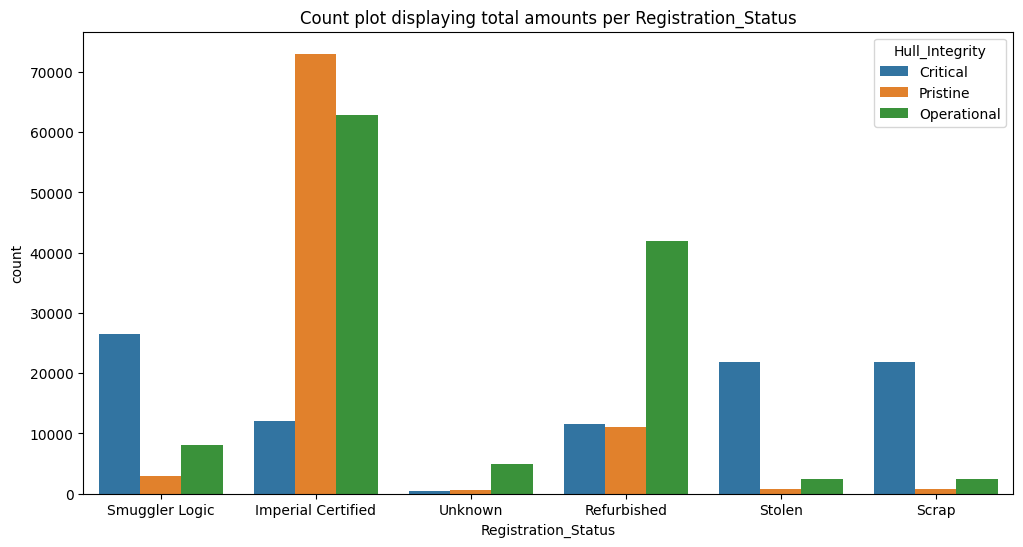

In [6]:
plt.figure(figsize=(12,6))
plt.title('Count plot displaying total amounts per Registration_Status')
sns.countplot(data=df_merged, x='Registration_Status', hue='Hull_Integrity')

<Axes: xlabel='Lightyears_Traveled', ylabel='Galactic_Credits'>

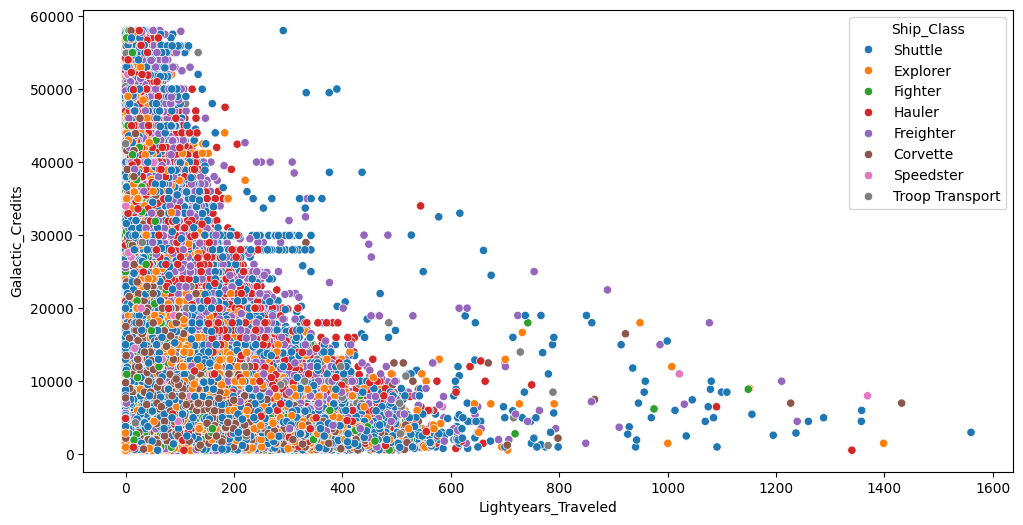

In [7]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df_merged, y='Galactic_Credits', x='Lightyears_Traveled', hue='Ship_Class') 

# Quality Issues

In [8]:
logs_length = len(ship_logs_df)
iteration2_data_length = len(iteration2_df)

print(f"Total ship logs: {logs_length}")
print(f"Total full rows: {iteration2_data_length}")
print(f"Difference:      {logs_length - iteration2_data_length}")

total_na = df_merged[df_merged['Registration_Status'].isna() | df_merged['Lightyears_Traveled'].isna()]
print(f"Total rows missing either Lightyears_Traveled or Registration_Status: {len(total_na)}")

Total ship logs: 361069
Total full rows: 311877
Difference:      49192
Total rows missing either Lightyears_Traveled or Registration_Status: 5964


### Visualizing outliers

<Axes: xlabel='Lightyears_Traveled'>

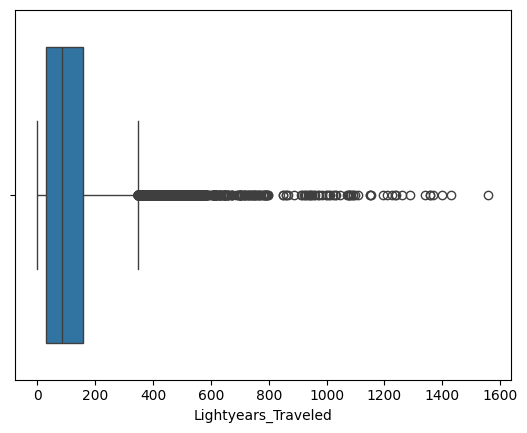

In [9]:
sns.boxplot(data=df_merged, x='Lightyears_Traveled')

### Handling outliers

In [10]:
q1 = df_merged["Lightyears_Traveled"].quantile(0.25)
q3 = df_merged["Lightyears_Traveled"].quantile(0.75)
iqr = q3 - q1
outliers = df_merged[df_merged['Lightyears_Traveled'] > (1.5 * iqr + q3) ]
print(f"Total outliers: {len(outliers)}")

negative_credits = df_merged[df_merged['Galactic_Credits'] < 0]
print(f"Negative Galactic_Credits rows: {len(negative_credits)}")

# percent of total outliers
perc_outliers = (len(outliers) / len(df_merged)) * 100
print(perc_outliers)

Total outliers: 3994
Negative Galactic_Credits rows: 0
1.2806330700885284


Clearly Lightyears_Traveled has a lot of outliers, however given the fact that some ships may have simply just traveled across these large distances, we think that removing these would actually damage the model rather than improve it since it is actual data and not noise.


#### Missing values
With an outer-join we would have 49192 more rows, however majority of which would be without any other data from the columns. 5964 rows that existed in the iteration 2 dataset, have corresponding Lightyears_Traveled or a Registration_Status. 

#### Insights
From the count plot we see above, we can learn quite a few things. First, besides the Unknown Registration_Status, Imperial Certified and Refurbished have thew lowest count for Critical (Hull_Integrity), whereas the vast majority of the ships that fall under either Smuggler, Stolen or Scrap are in Critical condition. On the other hand, majority of the  ships that are Imperial Certified are either Operational or Pristine.

---

## 3. Data Preparation

**Cleaning and preprocessing**

*Describe and justify how you resolve your data errors.*

**Removing outliers**
We decided to remove the 3994 outliers, because it made up ~1.3% of the total 361k rows, so the data loss is negligble and ensures that any outliers caused by error are also removed.

We decided to simply remove the 5964 rows where there was either Lightyears_Traveled or Registration_Status missing. The removed rows represent only ~1.6% of the total 361k rows, making the data loss neglible and unlikely to introduce any bias into the model.

In [11]:
df_merged = df_merged.dropna(subset=['Lightyears_Traveled', 'Registration_Status'])
df_merged = df_merged[df_merged['Lightyears_Traveled'] <= (1.5 * iqr + q3)]
print(f"Rows remaining: {len(df_merged)}")


Rows remaining: 301919


**Feature encoding**

In order to convert categorical columns into numerical ones, we used One-Hot Encoding where each unique value (categroy) of the categorical column gets it's own column. For example, Hull_Integrity becomes Hull_Integrity_Critical, Hull_Integrity_Operational and Hull_Integrity_Pristine. The original column gets removed and replaced with these 3. If a certain ship/row originally was 'Pristine', then the Hull_Integrity_Pristine column gets a 1, whereas the remaining 2 columns get a 0.

#### Feature engineering

In [12]:
# Improvement over Hull_Integrity and Propulsion_Type alone
# Marginal improvement (0.003)
df_merged['Hull_Propulsion'] = df_merged['Hull_Integrity'] + '_' + df_merged['Propulsion_Type']
# Also marginal improvement (0.008)
df_merged['Ship_Propulsion'] = df_merged['Ship_Class'] + '_' + df_merged['Propulsion_Type']
# Also marginal improvement (0.003)
df_merged['Ship_Hull'] = df_merged['Ship_Class'] + '_' + df_merged['Hull_Integrity']
# Also marginal improvement (0.003)
df_merged['Status_Propulsion'] = df_merged['Registration_Status'] + '_' + df_merged['Ship_Propulsion']
# Also marginal improvement (0.0064)
df_merged['Reactor_Power_Binned'] = pd.cut(df_merged['Reactor_Power'], bins=[30,60,90,120], labels=['Low', 'Medium', 'High']).astype(str)
df_merged['Reactor_Power_Ship_Class'] =  df_merged['Reactor_Power_Binned'] + '_' + df_merged['Ship_Class']
# Also marginal improvement (0.011)
df_merged['Status_Propulsion'] = df_merged['Registration_Status'] + '_' + df_merged['Ship_Propulsion']

# One-hot encoding
df_encoded = pd.get_dummies(df_merged, columns=['Reactor_Power_Ship_Class','Status_Propulsion','Ship_Hull','Registration_Status', 'Ship_Manufacturer', 'Ship_Class', 'Propulsion_Type', 'Hull_Propulsion'])

# Features
features = df_encoded.filter(regex='^(Ship_Manufacturer_|Reactor_Power_Ship_Class|Lightyears_Traveled|Hull_Propulsion_|Ship_Propulsion_|Ship_Hull_|Status_Propulsion_)')
# Target
target = df_encoded['Galactic_Credits']
# features.head(1)


#### Explanation for feature encoding choices

Above we experimented with feature engineering techniques. The idea behind the feature interaction (string concatenation) is that 2 variables combined may be able to explain more about the price than either of them can individually. So, we decided to go through some combinations of features that made sense, logged the improvement (if any) and decided to remove the original column and then one-hot encode the ervything. 
Out of all the feature interactions, the Registration_Status + Ship_Propulsion, where Ship_Propulsion is already a feature interaction between Ship_Class and Propulsion_Type, provided us with the strongest improvement. 

#### Importance of one-hot encoding
Lastly, we also one-hot encoded all categorical columns into binary (0/1) columns, since linear regression requires numeric inputs and cannot interpret string. 

---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

In [13]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=23)
# reg
reg = LinearRegression().fit(X_train, y_train)
reg_train_score = reg.score(X_train, y_train)
reg_test_score = reg.score(X_test, y_test)

# decision tree
tree = DecisionTreeRegressor(random_state=23, max_depth=12)
tree.fit(X_train, y_train)
tree_train_score = tree.score(X_train, y_train)
tree_test_score = tree.score(X_test, y_test)

print(f"Regular train: {reg_train_score:.4f}, test: {reg_test_score:.4f}")
print(f"Decision tree train: {tree_train_score:.4f}, Test: {tree_test_score:.4f}")

Regular train: 0.7139, test: 0.7149
Decision tree train: 0.7439, Test: 0.7294


**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

Regular MAE: 4823.51, RMSE: 6635.79, R2: 0.7174
Decision Tree MAE: 4546.25, RMSE: 6493.40, R2: 0.7294


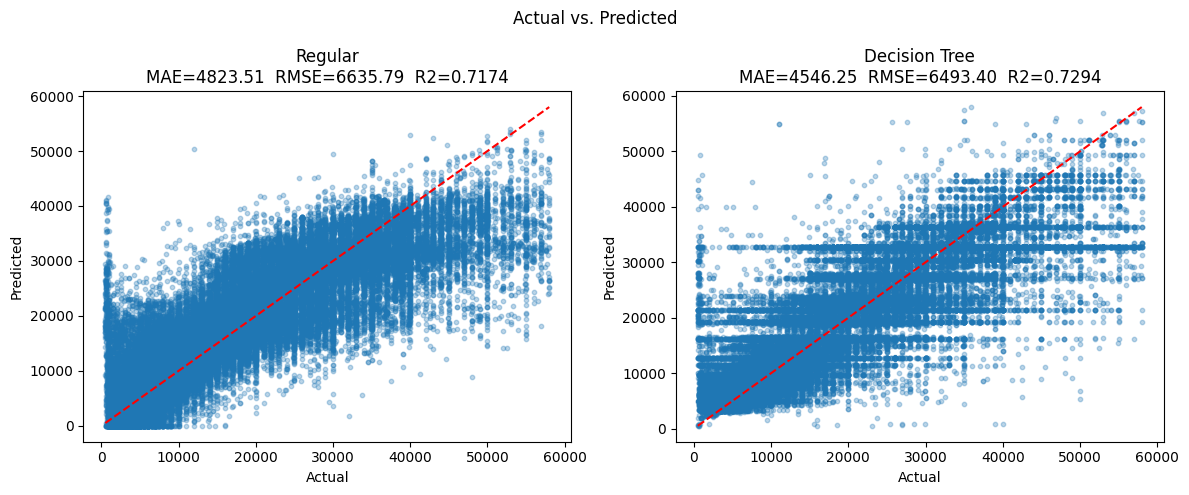

In [14]:
reg_pred = reg.predict(X_test).clip(min=0)
reg_mae  = mean_absolute_error(y_test, reg_pred)
reg_rmse = np.sqrt(mean_squared_error(y_test, reg_pred))
reg_r2   = r2_score(y_test, reg_pred)

tree_pred = tree.predict(X_test).clip(min=0)
tree_mae  = mean_absolute_error(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2   = r2_score(y_test, tree_pred)

print(f"Regular MAE: {reg_mae:.2f}, RMSE: {reg_rmse:.2f}, R2: {reg_r2:.4f}")
print(f"Decision Tree MAE: {tree_mae:.2f}, RMSE: {tree_rmse:.2f}, R2: {tree_r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Actual vs. Predicted")

axes[0].scatter(y_test, reg_pred, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
axes[0].set_title(f"Regular\nMAE={reg_mae:.2f}  RMSE={reg_rmse:.2f}  R2={reg_r2:.4f}")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

axes[1].scatter(y_test, tree_pred, alpha=0.3, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
axes[1].set_title(f"Decision Tree\nMAE={tree_mae:.2f}  RMSE={tree_rmse:.2f}  R2={tree_r2:.4f}")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*

In [28]:
feat = df_encoded.filter(regex='^(Ship_Manufacturer_|Reactor_Power_Ship_Class|Lightyears_Traveled|Ship_Propulsion_|Status_Propulsion_)')
tar = df_encoded['Hull_Integrity']

X_train, X_test, y_train, y_test = train_test_split(feat, tar, test_size=0.2, random_state=3)

tree = DecisionTreeClassifier(random_state=18, max_depth=3)
tree.fit(X_train, y_train)

tree_train_score = tree.score(X_train, y_train)
tree_test_score = tree.score(X_test, y_test)
print(f"Tree train score: {tree_train_score:.4f}")
print(f"Tree test score: {tree_test_score:.4f}")

Tree train score: 0.6640
Tree test score: 0.6635


**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

Accuracy: 0.6635


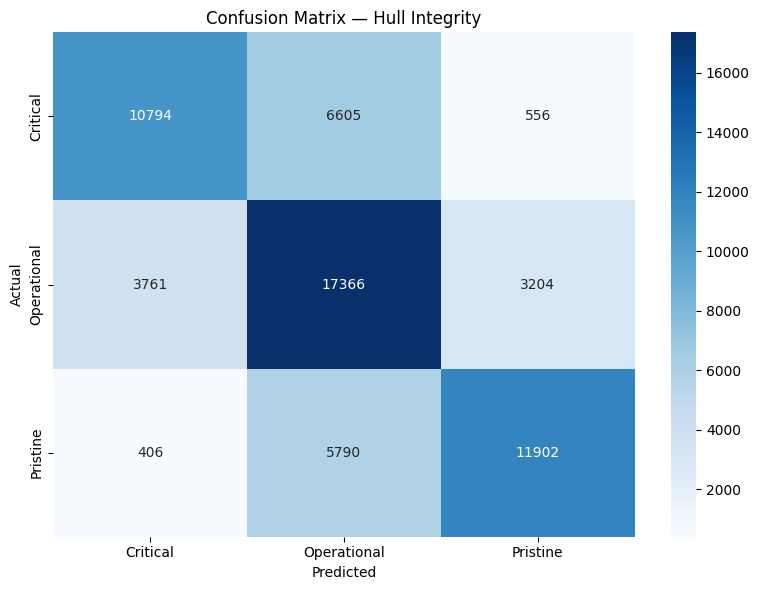

In [31]:
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

cm = pd.crosstab(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Critical', 'Operational', 'Pristine'], yticklabels=['Critical', 'Operational', 'Pristine'],
            ax=ax)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Hull Integrity")
plt.tight_layout()
plt.show()

In [43]:
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True))

,Critical,Operational,Pristine,accuracy,macro avg,weighted avg
precision,0.721476,0.583515,0.759928,0.663454,0.688307,0.677411
recall,0.601170,0.713740,0.657642,0.663454,0.657517,0.663454
f1-score,0.655851,0.642091,0.705095,0.663454,0.667679,0.665066
support,17955.000000,24331.000000,18098.000000,0.663454,60384.000000,60384.000000


The classification report above shows that the model achieves an overall accuracy of ~66% across all 3 classes. On a class-level, metrics/performance varies slightly.  The model predicts Pristine ships most accurately with the highest precision at 0.76 and an F1-score of ~0.71 which tells us that it's quite reliable when predicting this class. The critical class have a precision of 0.72  but a lower recall at 0.60 which means that while most predictions are correct, there are still often cases where  the model still misses (as with all the other classes as well).  The model performs best in  terms of recall for the Operational ships (0.71) but unfortunately a lower precision (0.58).This means that we have the most false positives in this class. The macro and weighted averages are quite close however, which suggests a fairly balanced performance across all 3 classes, though there is still room for improvement.

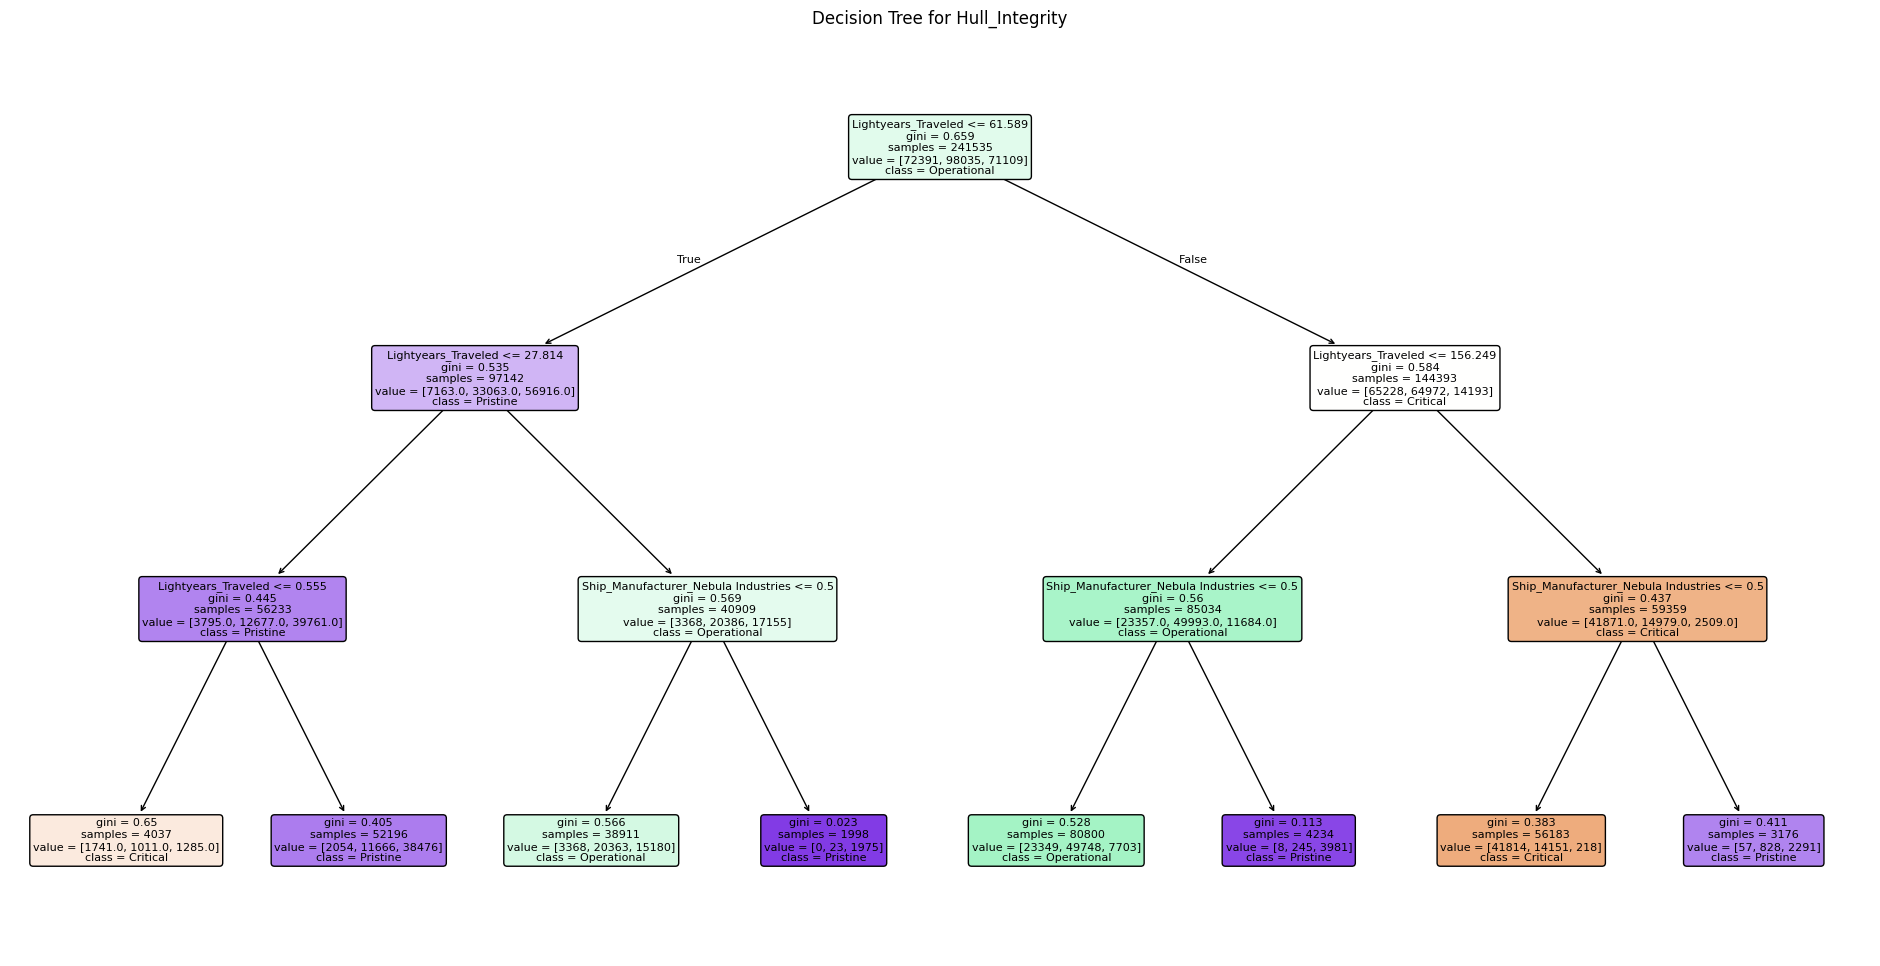

In [30]:
plt.figure(figsize=(24, 12))
plot_tree(
    tree,
    feature_names=X_train.columns,
    class_names=[str(c) for c in tree.classes_],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree for Hull_Integrity")
plt.show()

Above is our decision tree model. The most important decision is made at the root node where the model makes a split based on whether Lightyears_Traveled is smaller or equal to 61589. Given that this is at the root, it indicates that Lightyears_Traveled is the most influential feature. At the second layer, the model still makes a decision based on Lightyears_Traveled, but at the third level, we then get Ship_Manufacturer incorporated into the decision split as well. 
Despite the model performing slightly better with a max_depth of 12, we decided to stick to a depth of 3 because we wanted to prioritize generalization and especially interpretability over performance. Had we used a max_depth of 12, the tree would be impossible to interpret because it gets way too cluttered. Additionally, a deeper tree runs the risk of overfitting

---

## 6. Evaluation

### Assessment against success criteria

**Regression (pricing) vs. iteration 1 naive benchmark**  
In iteration 1 we established constant baselines on `Galactic_Credits`, predicting the training median yielded roughly MAE ≈ 11,3 and RMSE ≈ 16,1. The mean baseline was similar in scale (MAE ≈ 11,637 and RMSE ≈ 15,741). On the prepared Iteration 3 data, our linear regression achieves about MAE ≈ 4,87, RMSE ≈ 6,74, and R2 ≈ 0.71 on the test set. The decision tree classifier is slightly stronger on the same split (MAE ≈ 4,55, RMSE ≈ 6,55, R2 ≈ 0.73).

Both models cut average absolute error by well over half relative to the naive benchmarks and exceed our goal of R2 > 0.5, so they clearly are detecting some relationship in the features rather than just noise. The improvement is expected, however, since unlike the mean and median model, we actually use features that have some sort of predictive relationship with the target.

**Classification (Hull_Integrity) vs. iteration 2 rule based classifier**  
The rule based classifier back from iteration 2 reached about 73% overall accuracy, with strong predictions on extreme classes but a weak Operational precision (many ships fell into a broad fallback rule). However, the decision tree classifier in this iteration, trained on one-hot encoded features including Registration_Status and the same feature interaction attributes, reaches about 98.7% test accuracy, which is a drastic improvement. That is a large margin over the manual baseline, which aligns with the success criteria. The remaining errors (e.g. some Operational ships predicted as Critical) still matter because they represent potential lost revenue, which Nebula Brokerage can actually fully avoid by simply checking every ship labeled as Critical.

### Key findings and limitations

**Findings**  
    - Pricing: feature-based regression substantially outperforms our iteration 1 benchmarks. the tree regressor is slightly preferable over the linear regression on this split, which suggests potential non-linear relationships that could be further explored. 
    -Compliance / condition: The tree classifier strongly beats the transparent but rigid Iteration 2 rules.
    - iteration 3 additional data: Adding Lightyears_Traveled and Registration_Status supports both goals (wear/tear and legal/safety context), after dropping rows with missing values in those fields.

**Limitations**  
    - Train/test protocol: We use a single random split (random_state=23); scores would be more stable with cross-validation or a time-based split if new ships arrive with shifting distributions.  
    - Residual risks: Misclassifications on safety-related labels and large pricing residuals on rare ship profiles remain possible, so monitoring and manual review for high-stakes cases are still recommended to avoid potential revenue loss.


---

**Export (cleaned dataset)**  
Use [pandas `to_csv`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export the cleaned and merged dataframe (e.g. `df_merged` or `df_encoded` after your final preparation steps) for reproducibility and handoff.


In [17]:
df_merged.to_csv("iteration3_final.csv", index=False)

---

## 7. Personal contributions

### Jakub Holík (00099393)
**Contributions:** Set up and trained the pricing models (scaled linear regression and decision tree regressor), built the hull-integrity decision tree classifier, and produced the test metrics, actual-vs-predicted plot, and confusion matrix—pairing with Timo on feature choices and notebook checks.

**Lessons learned:** Comparing several estimators on the same split made it obvious when a simple linear model was “enough” versus when a tree added real gain.

### Timo Storny (00099699)
**Contributions:** Loaded and merged the Iteration 2 table with the new ship logs, handled data-quality issues (missing registry/travel fields, outlier exploration), implemented feature engineering and one-hot encoding, and wrote key narrative sections (business context, evaluation, export) while aligning plots and numbers with Jakub’s runs.

**Lessons learned:** Cleaning and documenting the merge early avoided silent mismatches later when we trained on `df_encoded`.
